# Imports and Data

In [1]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from PIL import Image
import json
from pathlib import Path

In [2]:
sns.set_theme(style="whitegrid")

In [5]:
DATA_DIR = "../data/combined-dataset-16class/train"
base_dataset = datasets.ImageFolder(root=DATA_DIR)
classes = base_dataset.classes
print(f"Total Classes: {len(classes)}")
print(f"Total Training Images: {len(base_dataset)}")

Total Classes: 16
Total Training Images: 2459


# Classes

In [4]:
class_counts = {class_name: 0 for class_name in classes}
for _, class_idx in base_dataset.samples:
    class_counts[classes[class_idx]] += 1

df_counts = pd.DataFrame(list(class_counts.items()), columns=['Disease Class', 'Image Count'])
df_counts = df_counts.sort_values(by='Image Count', ascending=False)
df_counts

,Disease Class,Image Count
7,Potato Leaf Blight,263
5,Corn Leaf Blight,258
15,Tomato Septoria Leaf Spot,215
1,Apple Rust Leaf,197
2,Apple Scab leaf,190
6,Corn Rust Leaf,186
12,Tomato Leaf Late Blight,167
10,Tomato Leaf Bacterial Spot,163
11,Tomato Leaf Early Blight,159
14,Tomato Mold Leaf,149


/tmp/ipykernel_7888/1104959404.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Image Count', y='Disease Class', data=df_counts, palette='viridis')


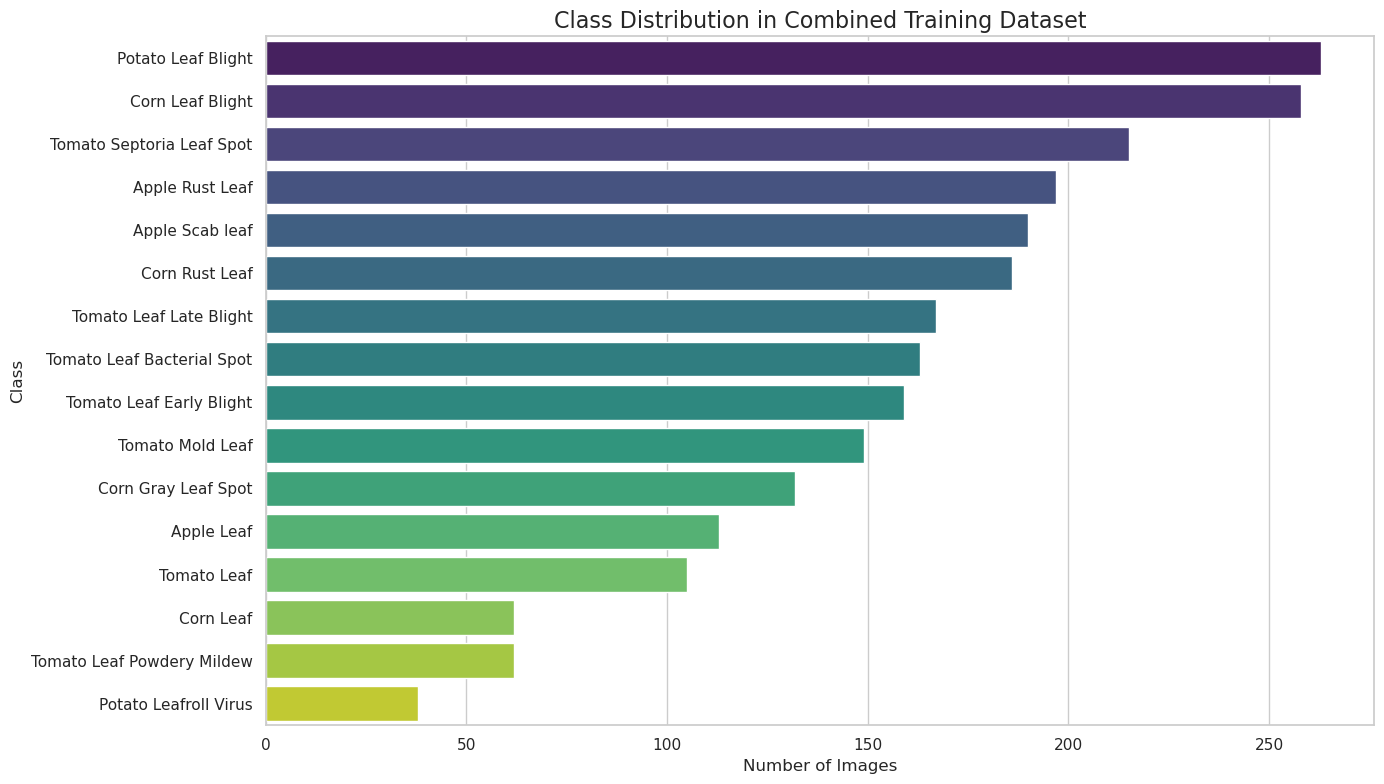

In [6]:
plt.figure(figsize=(14, 8))
sns.barplot(x='Image Count', y='Disease Class', data=df_counts, palette='viridis')
plt.title('Class Distribution in Combined Training Dataset', fontsize=16)
plt.xlabel('Number of Images', fontsize=12)
plt.ylabel('Class', fontsize=12)
plt.tight_layout()
plt.show()

# Calculate standard inverse class weights

In [7]:
# Formula: total_samples / (num_classes * count_for_class)
total_samples = len(base_dataset)
num_classes = len(classes)

weights = []
for class_name in classes:
    count = class_counts[class_name]
    weight = total_samples / (num_classes * count)
    weights.append(weight)

In [8]:
class_weights_tensor = torch.FloatTensor(weights)
weight_dict = {class_name: float(weight) for class_name, weight in zip(classes, weights)}
print(f"class_weights = {weight_dict}")

class_weights = {'Apple Leaf': 1.3600663716814159, 'Apple Rust Leaf': 0.7801395939086294, 'Apple Scab leaf': 0.8088815789473685, 'Corn Gray Leaf Spot': 1.1642992424242424, 'Corn Leaf': 2.4788306451612905, 'Corn Leaf Blight': 0.595687984496124, 'Corn Rust Leaf': 0.8262768817204301, 'Potato Leaf Blight': 0.5843631178707225, 'Potato Leafroll Virus': 4.0444078947368425, 'Tomato Leaf': 1.463690476190476, 'Tomato Leaf Bacterial Spot': 0.9428680981595092, 'Tomato Leaf Early Blight': 0.9665880503144654, 'Tomato Leaf Late Blight': 0.9202844311377245, 'Tomato Leaf Powdery Mildew': 2.4788306451612905, 'Tomato Mold Leaf': 1.0314597315436242, 'Tomato Septoria Leaf Spot': 0.7148255813953488}


In [9]:
weights_path = Path(DATA_DIR).parent / "class_weights.json"
with open(weights_path, 'w') as f:
    json.dump(weight_dict, f, indent=4)
print(f"Weights successfully saved to: {weights_path}")

Weights successfully saved to: ../data/combined-dataset-16class/class_weights.json


# Gaussian Noise

In [10]:
class AddGaussianNoise(object):
    def __init__(self, mean=0., std=0.05):
        self.std = std
        self.mean = mean
        
    def __call__(self, tensor):
        return tensor + torch.randn(tensor.size()) * self.std + self.mean

In [11]:
clean_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

noisy_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    AddGaussianNoise(mean=0.0, std=0.05)
])

In [12]:
sample_path = base_dataset.samples[0][0]
img = Image.open(sample_path).convert('RGB')

In [13]:
clean_img = clean_transform(img).permute(1, 2, 0).numpy()
noisy_img = noisy_transform(img).permute(1, 2, 0).numpy()
noisy_img = np.clip(noisy_img, 0, 1)

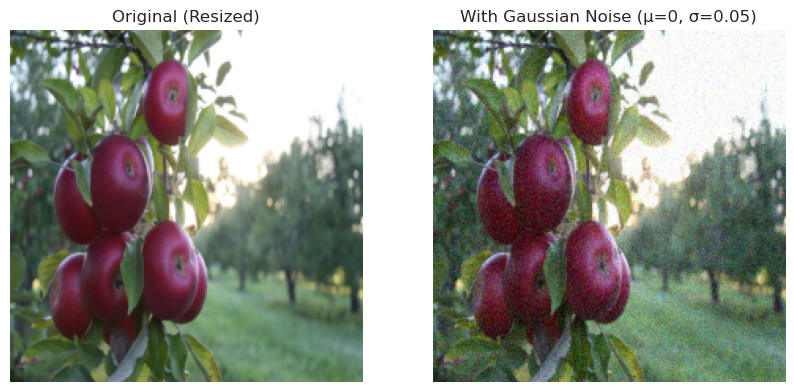

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(clean_img)
axes[0].set_title("Original (Resized)")
axes[0].axis('off')

axes[1].imshow(noisy_img)
axes[1].set_title("With Gaussian Noise (\u03BC=0, \u03C3=0.05)")
axes[1].axis('off')

plt.show()